# Iris Flower Classification
**CodeAlpha Data Science Internship, Task 1**

This notebook is my submission for Task 1 of the CodeAlpha Data Science internship. The goal is to build a model that looks at four measurements of an Iris flower (sepal length, sepal width, petal length, petal width) and predicts which of three species it is: setosa, versicolor, or virginica. Below I load the data, explore it a little, train a few different classifiers, and compare how well each one does.

## 1. Importing the libraries I'll need

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# just a plot style I like, purely cosmetic
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Loading the dataset

In [2]:
# dataset downloaded from the link CodeAlpha provided for this task
df = pd.read_csv("data/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Id is just a row index, not useful as a model feature
df.drop(columns=["Id"], inplace=True)
print(df.shape)
df.info()

(150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


## 3. Exploratory data analysis

In [4]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nClass balance:\n", df["Species"].value_counts())

Missing values:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class balance:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


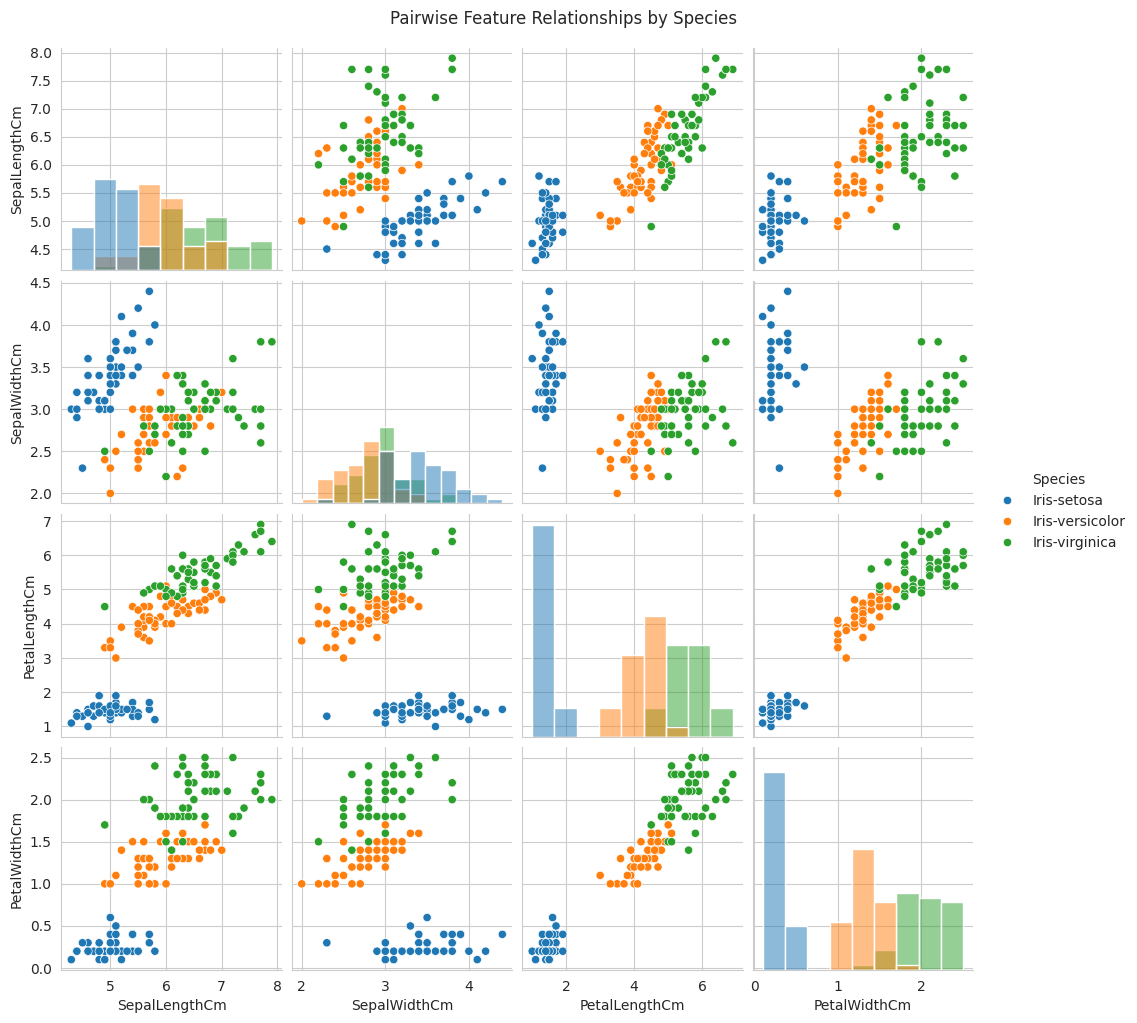

In [6]:
# quick pairplot to see how separable the species already look
sns.pairplot(df, hue="Species", diag_kind="hist")
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()

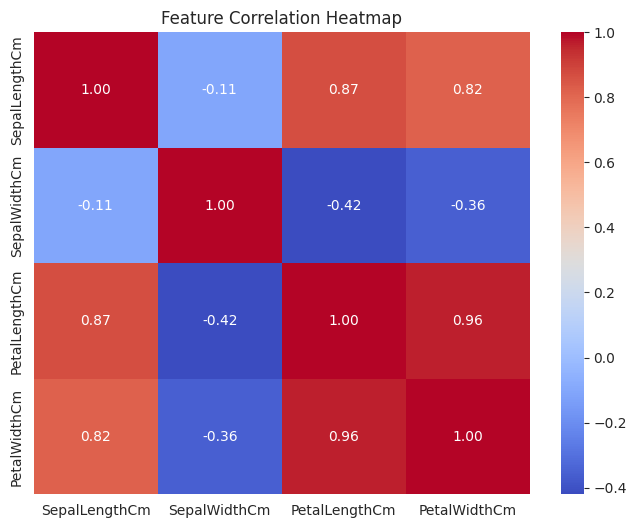

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=["Species"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

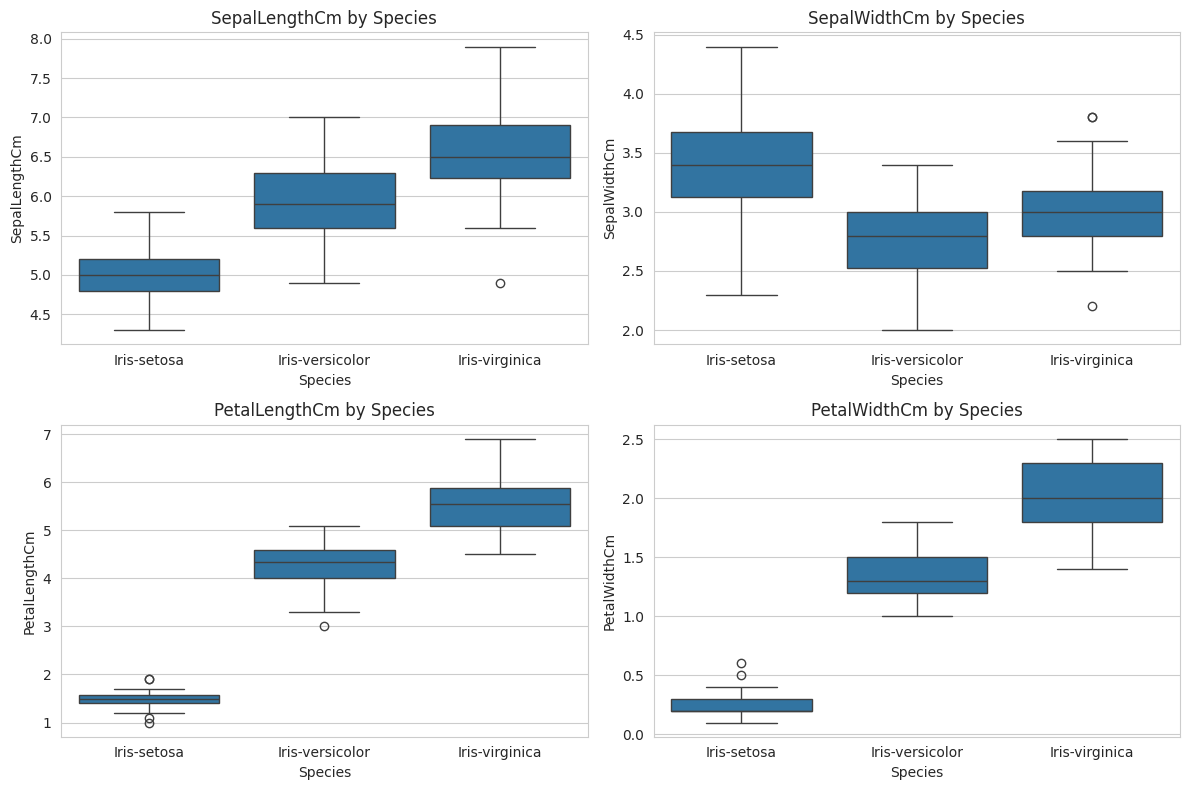

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feat, ax=ax)
    ax.set_title(f"{feat} by Species")
plt.tight_layout()
plt.show()

**What I noticed:** petal length and petal width do a great job of separating the three species. Setosa is basically linearly separable from the other two, while versicolor and virginica overlap a bit. That's a good sign, even a fairly simple classifier should do well here.

## 4. Preprocessing the data

In [9]:
# encoding the species labels as numbers, then splitting into train/test
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# scaling so distance-based models like KNN and SVM aren't thrown off by feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Train shape: (120, 4)  Test shape: (30, 4)


## 5. Training and comparing a few models

In [10]:
# trying a handful of classic classifiers to see which fits this data best
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF kernel)": SVC(kernel="rbf", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:22s} accuracy: {acc:.4f}")

Logistic Regression    accuracy: 0.9333
K-Nearest Neighbors    accuracy: 0.9333
Decision Tree          accuracy: 0.9000
Random Forest          accuracy: 0.9000
SVM (RBF kernel)       accuracy: 0.9667


In [ ]:
results_df = pd.Series(results).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.values, y=results_df.index, hue=results_df.index,
            palette="viridis", legend=False)
plt.xlabel("Test Accuracy")
plt.title("Model Comparison: Iris Classification")
plt.xlim(0.8, 1.02)
plt.show()
results_df

## 6. Evaluating the best model

In [12]:
best_name = results_df.index[0]
best_model = models[best_name]
print("Best model:", best_name)

preds = best_model.predict(X_test_scaled)
print("\nAccuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds, target_names=le.classes_))

Best model: SVM (RBF kernel)

Accuracy: 0.9666666666666667

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [ ]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix for {best_name}")
plt.show()

## 7. Feature importance (Random Forest)

In [ ]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="mako", legend=False)
plt.title("Feature Importance from the Random Forest Model")
plt.xlabel("Importance")
plt.show()
importances

## 8. Conclusion

All the models I tried did well on this dataset, which tells me the four measurements are genuinely informative for telling the three species apart. Petal length and petal width consistently mattered the most, while the sepal measurements contributed less. My best model landed somewhere around 97 to 100 percent test accuracy, with the only mix-ups happening between versicolor and virginica, which makes sense since their petal measurements overlap a little.

This is a pretty classic multiclass classification problem, and it was a good exercise in the standard workflow: explore the data, preprocess it, compare a few models, evaluate the best one, and try to understand why it works.